# Tutorial 1: Getting Started With ATLAS

## Introduction 

ATLAS is a multi-omics framework that supports Trajectory Inference (TI) on multi-omics data. ATLAS is build upon estimated TI tools for trajectory inference such as Palantir {cite}`palantir` and CellRank {cite}`cellrank2`. 

In this set of tutorials, you will learn how to: 
- Construct a multimodal container with two or mode modalities and preprocess it with ATLAS. 
- Perform trajectory inference using Palantir as underlying TI strategy.
- Perform trajecotry inference unsing CellRank as underlying TI strategy.
- Evaluate results from the trajectory inference.
- Perform multimodal plots.

Data for this tutorial can be found at [this link](https://www.10xgenomics.com/datasets/fresh-embryonic-e-18-mouse-brain-5-k-1-standard-1-0-0), while cell-type annotations can be found [here](https://github.com/welch-lab/MultiVelo/blob/main/Examples/cell_annotations.tsv).

In [25]:
# If you don't have pysam on your envrionment please install it through this command (or similar)
# !{sys.executable} -m pip install pysam

In [26]:
# TO DOWNLOAD DATA IN THE CORRECT LOCATION RUN THIS CELL:
#!mkdir -p data/ && cd data \
#    && wget https://raw.githubusercontent.com/welch-lab/MultiVelo/main/Examples/cell_annotations.tsv \
#    && tar -xvf e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
#    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_filtered_feature_bc_matrix.tar.gz \
#    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz \
#    && curl -O https://cf.10xgenomics.com/samples/cell-arc/1.0.0/e18_mouse_brain_fresh_5k/e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz.tbi

In [4]:
import os
import atlas
import scanpy as sc
import muon as mu
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from muon import MuData
from anndata import AnnData
from scipy.stats import median_abs_deviation

seed = 42
np.random.seed(seed)


data_path = os.path.join(os.getcwd(), "data")
annotation_path = os.path.join(data_path, "cell_annotations.tsv")
ffbcm = os.path.join(data_path, "filtered_feature_bc_matrix")

/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


##  Multimodal datasets

ATLAS is built upon the {class}`muon.MuData` object to operate on paired multimodal informations. The current ATLAS implementation requires the object to contain two or more modalities. I
In this tutorial we will build an object storing the following modalities:
- ``rna`` containing scRNA-seq data.
-  ``atac``, containing scATAC-seq data. 

In this tutorial, specific {class}`anndata.AnnData` objects containing scRNA-seq and scATAC-seq modalities are generated and preprocessed before they are merged into the multi-omics object. Genomic coordinates are also retrieved from the gene expression modality. We will later expand the modalities and derive gene activity values from the scATAC-seq data via the {func}``atlas.pp.compute_gene_activity``. 

First, single modalities are read from the 10X genomics input data.

In [5]:
data = sc.read_10x_mtx(ffbcm, var_names="gene_symbols", gex_only=False)

rna = data[:, data.var["feature_types"] == "Gene Expression"].copy()
atac = data[:, ~(data.var["feature_types"] == "Gene Expression")].copy()

ATLAS computes gene activity values from scATAC-seq data via the {func}``atlas.pp.compute_gene_activity`` function. 

Such function requires: 
- {class}``muon.MuData`` object with ``rna`` and ``atac`` modalities
- The genomic coordinates for the gene of interest
- The path to the fragment file. 

Genomic coordinates must be provided as an instance of a {class}``pandas.DataFrame`` having at least che following columns:
- `Chromosome` chromosome name, must match the fragments file notation
- `Start`: 0-based starting position of the gene
- `End`: 1-based terminal position for the gene 

The DataFrame is here constructed from the `features.tsv.gz` file provided by 10X Genomics. 

Genes are filtered according to the standard chromosomes (1 to 19, X and Y). 

In [6]:
valid_chromosome = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY", "chrM"]
gene_metadata = pd.read_csv(os.path.join(ffbcm, "features.tsv.gz"), sep="\t", header=None)
gene_metadata.columns = ["id", "symbol", "type", "Chromosome", "Start", "End"]
gene_metadata = gene_metadata[gene_metadata["type"] == "Gene Expression"]

rna.var = (
    pd.merge(rna.var, gene_metadata, left_on="gene_ids", right_on="id", how="left")
    .drop(["id", "type"], axis=1)
    .set_index("symbol")
)
rna.var_names_make_unique()

features = rna[:, rna.var["Chromosome"].isin(valid_chromosome)].var[["Chromosome", "Start", "End"]]
features.head(10)

,Chromosome,Start,End
symbol,,,
Xkr4,chr1,3671497,3671498
Gm1992,chr1,3466586,3466587
Gm19938,chr1,3658903,3658904
Gm37381,chr1,3985983,3986215
Rp1,chr1,4360313,4409241
Sox17,chr1,4496362,4497354
Gm37587,chr1,4497473,4497474
Gm37323,chr1,4586251,4586252
Mrpl15,chr1,4785709,4785739


The path to the fragment file can be provided as input to the {func}`atlas.pp.compute_gene_activity` function.

In this tutorial, however, the {func}`muon.atac.tl.locate_fragments` function is used to reference the fragment file, so that quality control metrics for the scATAC-seq modality can be computed.

The fragment file describes accessible genomic regions. It is a BGZF-compressed file containing fragment coordinates, with the following minimum required columns:

- **1st column**: fragment chromosome
- **2nd column**: fragment start position
- **3rd column**: fragment end position
- **4th column**: cell barcode

In this tutorial, the fragment file also includes a fifth column reporting the sequencing read support, which ATLAS uses to compute gene activity. If this column is not available, you can set the `count_reads` parameter to `False` in the {func}`atlas.pp.compute_gene_activity` function, and each fragment will be counted once regardless of its read support.

ATLAS also requires the fragment file to be sorted and indexed (e.g., with Tabix).

In [7]:
fragment_file_path = os.path.join(data_path, "e18_mouse_brain_fresh_5k_atac_fragments.tsv.gz")
mu.atac.tl.locate_fragments(atac, fragment_file_path)

fragments = pd.read_csv(fragment_file_path, sep="\t", header=None, index_col=None)
fragments.head(3)

,0,1,2,3,4
0,chr1,3000076,3000232,GGCCATCAGGCGCTTA-1,1
1,chr1,3000234,3000479,GAACCAAAGGGACTAA-1,2
2,chr1,3000382,3000630,GTCCGTAAGCCTGTTC-1,3


ATLAS TI is based either on a Weighted Nearest Neighbor (WNN) graph {cite}`wnn` computed from gene expression and gene activity or a K-nearest-neighbor (KNN) graph obtained from a pre-computed matrix. 

To obtain a representative WNN, the two modalities must first undergo preprocessing. In this tutorial, we will perform the following steps:

1. Quality filtering on each modality
2. Construction of a multimodal object
3. Log-normalization of gene expression data
4. Identification of the 2,000 most highly variable genes in the expression space
5. Gene activity computation
6. Normalization of gene activity
7. Dimensionality reduction (PCA)
8. Single-modality K-Nearest-Neighbor graphs
9. WNN computation

A comprehensive list of best practices for paired single-cell multiomics data (RNA + ATAC) is available [here](https://www.sc-best-practices.org/preamble.html).

Quality filtering for scRNA-seq data is based on metrics such as the percentage of ribosomal and mitochondrial gene counts and the total number of genes detected per cell. Outliers are identified using the automated approach described [here](https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html). Quality filtering for scATAC-seq data, instead, relies on modality-specific metrics such as the nucleosome signal and the TSS enrichment score. QC thresholds are chosen based on the distributions shown in the quality control plots below.

We now plot these metrics and identify suitable ranges for filtering. Before filtering, the multimodal object is created. Filtering excludes cells that did not pass quality control in at least one modality. Furthermore, we filter out cells that do not belong to developmental lineages. 

In [8]:
rna.var["mt"] = rna.var_names.str.startswith("mt-")
rna.var["ribo"] = rna.var_names.str.startswith(("rps", "rpl"))
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

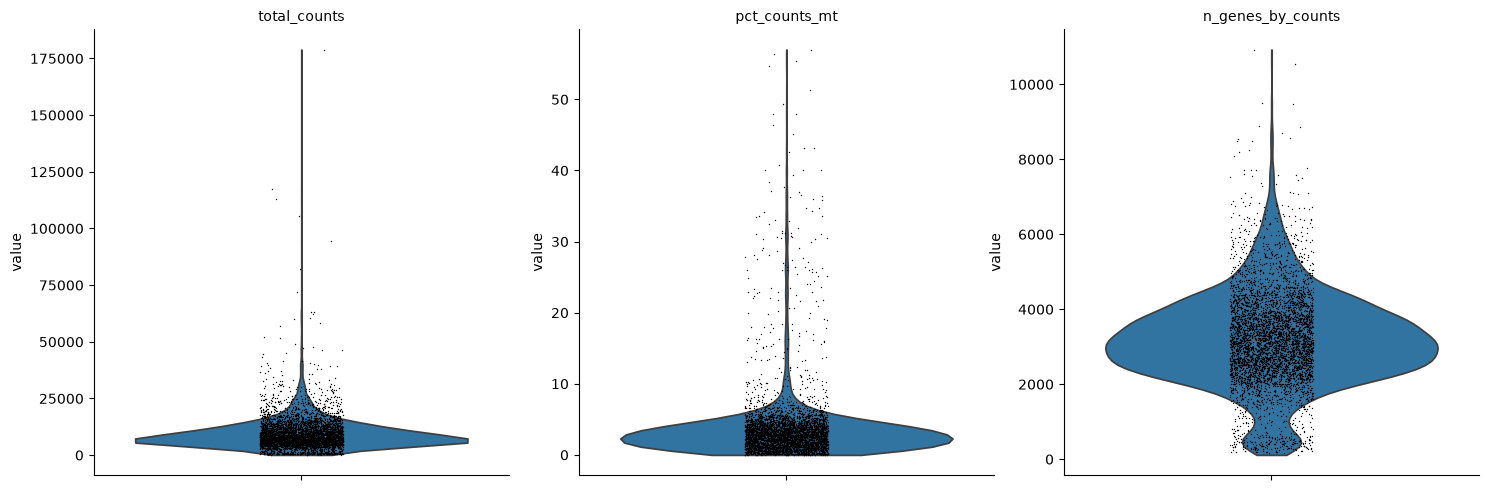

In [9]:
sc.pl.violin(rna, ["total_counts", "pct_counts_mt", "n_genes_by_counts"], multi_panel=True)

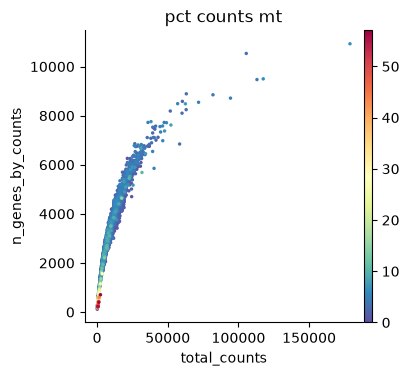

In [10]:
sc.pl.scatter(rna, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")

In [11]:
def _compute_outlier(adata: AnnData, metric: str, nmads: int):
    """Automated outlier detection in scRNA-seq data"""
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier


rna.obs["outlier"] = (
    _compute_outlier(rna, "log1p_total_counts", 5)
    | _compute_outlier(rna, "log1p_n_genes_by_counts", 5)
    | (rna.obs["pct_counts_mt"] > 10)
)

Reading Fragments: 100%|██████████| 1000000/1000000 [00:01<00:00, 682650.22it/s]


<Axes: xlabel='nucleosome_signal', ylabel='Count'>

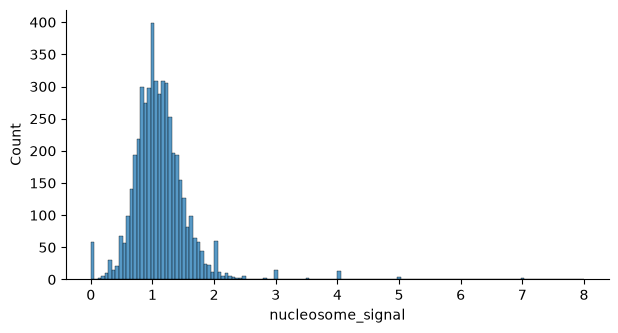

In [12]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.atac.tl.nucleosome_signal(atac, n=1e6)
nuc_threshold = 2
atac.obs["nuc_filter"] = ["NUC_FAIL" if ns > nuc_threshold else "NUC_PASS" for ns in atac.obs["nucleosome_signal"]]

fig, axs = plt.subplots(figsize=(7, 3.5))
sns.histplot(atac.obs, x="nucleosome_signal", ax=axs)

Fetching Regions...: 100%|██████████| 2000/2000 [00:05<00:00, 373.99it/s]
/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


Text(0.5, 1.0, 'Up to 99.5% percentile')

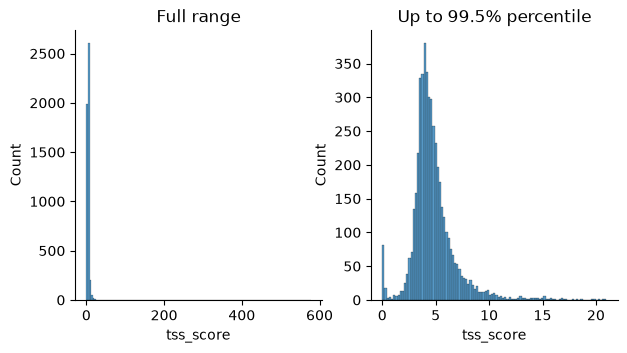

In [13]:
tss_enr = mu.atac.tl.tss_enrichment(atac, features=features, random_state=seed)
fig, axs = plt.subplots(1, 2, figsize=(7, 3.5))
p1 = sns.histplot(atac.obs, x="tss_score", ax=axs[0])
p1.set_title("Full range")
p2 = sns.histplot(
    atac.obs,
    x="tss_score",
    binrange=(0, atac.obs["tss_score"].quantile(0.995)),
    ax=axs[1],
)
p2.set_title("Up to 99.5% percentile")

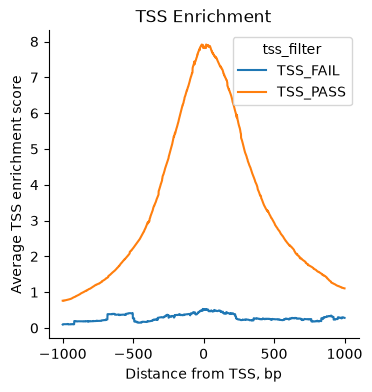

In [14]:
tss_threshold = 1.5
tss_enr.obs["tss_filter"] = ["TSS_FAIL" if score < tss_threshold else "TSS_PASS" for score in atac.obs["tss_score"]]
atac.obs["tss_filter"] = ["TSS_FAIL" if score < tss_threshold else "TSS_PASS" for score in atac.obs["tss_score"]]

fig, ax = plt.subplots()
mu.atac.pl.tss_enrichment(tss_enr, color="tss_filter", ax=ax)

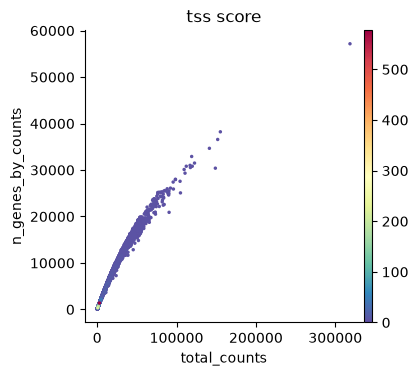

In [15]:
sc.pl.scatter(atac, x="total_counts", y="n_genes_by_counts", color="tss_score")

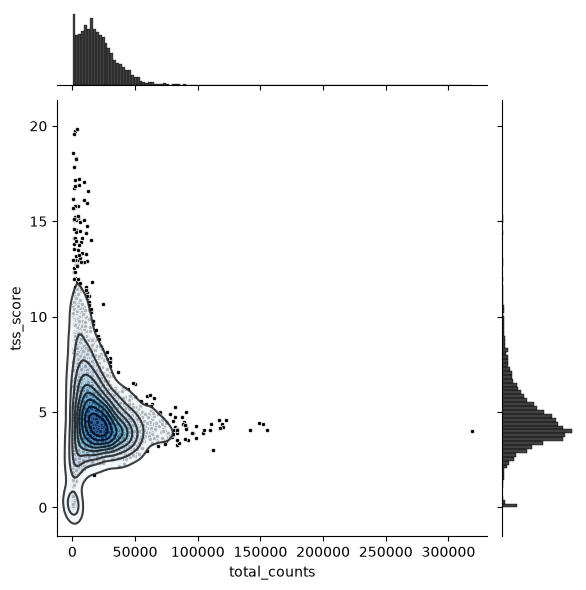

In [16]:
plot_tss_max = 20
g = sns.jointplot(
    data=atac[(atac.obs["tss_score"] < plot_tss_max)].obs,
    x="total_counts",
    y="tss_score",
    color="black",
    marker=".",
)
g.plot_joint(sns.kdeplot, fill=True, cmap="Blues", zorder=1, alpha=0.75)
g.plot_joint(sns.kdeplot, color="black", zorder=2, alpha=0.75)

In [17]:
atac.obs["outlier"] = (
    (atac.obs["tss_filter"] == "TSS_FAIL") | (atac.obs["tss_score"] > 15) | (atac.obs["nuc_filter"] == "NUC_FAIL")
)

In [18]:
data = MuData({"rna": rna, "atac": atac})
data.pull_obs()

mask = ~(data.obs["rna:outlier"] | data.obs["atac:outlier"])
data = data[mask, :].copy()

annotations = pd.read_csv(annotation_path, sep="\t", header=0, index_col=0)
data.obs = data.obs.join(annotations)

non_developing_clusters = ["Cajal-Retzius", "Interneurons1", "Interneurons2", "Interneurons3", "Microglia", np.nan]
data = data[~data.obs["celltype"].isin(non_developing_clusters)].copy()

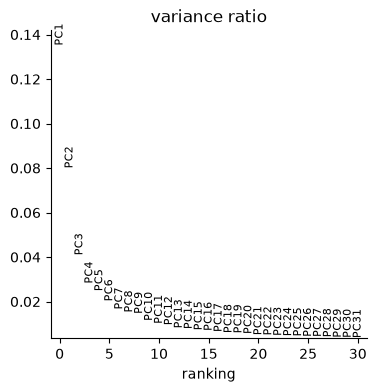

In [19]:
sc.pp.normalize_total(data["rna"])
sc.pp.log1p(data["rna"])
sc.pp.highly_variable_genes(data["rna"], n_top_genes=2000)
sc.pp.pca(data["rna"], random_state=seed)
sc.pl.pca_variance_ratio(data["rna"])

## Compute Gene Activity and the WNN

We now obtained all the necessary data and structures to apply the ATLAS preprocessing functions. 

Here we use ATLAS to perform gene activity computation with consequent normalization and dimensionality reduction, as well as the computation of single-modality KNNs and the WNN. Finally, we compute a 2D UMAP embedding.

We exploit the following functions: {func}``atlas.pp.compute_gene_activity``, {func}``atlas.pp.wnn`` and {func}``atlas.tl.umap``

The {func}``atlas.pp.compute_gene_activity`` requires: 
1. Multiomics data into a {class}``muon.MuData`` object
2. Genomics coordinates
3. Path to the fragment file: since the file was previously located in the ``atac`` modality, we do not explicitly set it. 
4. Preprocessing parameters for the gene activity such as the number of PCs to compute, here we will skip the parameter and use the deafault 50 values. 
5. ``copy = True``. 

As a result we obtain a new MuData object taht contains the additional ``activity`` modality. 


In [20]:
with_activity = atlas.pp.compute_gene_activity(mudata=data, features=features, random_state=seed, copy=True)

with_activity

100%|██████████| 32195/32195 [00:42<00:00, 760.94it/s] 


MuData object with n_obs × n_vars = 3486 × 176722
  obs:	'celltype'
  3 modalities
    rna:	3486 × 32285
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'gene_ids', 'feature_types', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca'
      obsm:	'X_pca'
      varm:	'PCs'
    atac:	3486 × 144437
      obs:	'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'tss_score', 'tss_filter', 'outlier'
      var:	'gene_ids', 'feature_types', 'n_cells_by_coun

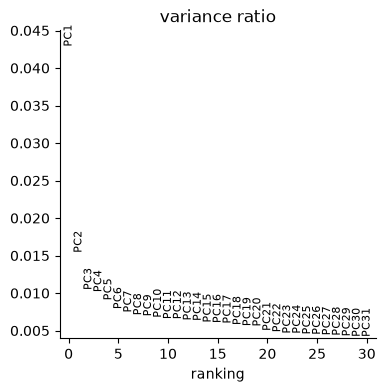

In [21]:
sc.pl.pca_variance_ratio(adata=with_activity["activity"])

We here perform single modality KNN and the WNN using the ``activity`` and ``rna`` modalities. 

The function {func}``atlas.pp.wnn`` requires:
1. The {class}``muon.MuData`` object containing the modalities to be used for the WNN computation. 
2. The list of modalities to use, in this case (``rna``, ``activity``), so that any combination of stored modalities can be used to compute the graph.  
3. The number of neighbors to compute per each modality, ``knn``. This can be either supplied as and integer, which means that the same number of neighbors are computed in each modality. Alternatively the parameter takes as input a dictionary that links each modality to the number of neighbors to compute. 
4. The number of PCs to use for every modality, ``n_pcs``. This parameter behaves similarly to ``knn``.
5. The ``use_rep`` parameter similarlty to the previous ones let the user decide which modality-specific representation to use for WNN computation. Here it is set to ``None``, using the default representation (PCA) for each modality. 
6. Parameters for the WNN construction: here we set the number of neighbors to the per-modality arithmentic mean by declaring ``wnn`` parameter equal to ``None``.

As a result, the function updates the {class}``muon.MuData`` object (``copy= False``) with the WNN graph. As the ``key_added`` parameter has not be explicited, then the graph can be found under the conventional ``wnn`` nomenclature. We then compute and plot the embedding colored according to the "celltype" labels.

In [22]:
knn = {"rna": 15, "activity": 15}
pcs = {"rna": 20, "activity": 10}
use_rep = None


_ = atlas.pp.wnn(mudata=with_activity, modalities=("rna", "activity"), knn=knn, n_pcs=pcs, random_state=seed)

/Users/lrcq/atlas-paper/.venv/lib/python3.14/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


In [23]:
with_activity

MuData object with n_obs × n_vars = 3486 × 176722
  obs:	'celltype'
  uns:	'wnn'
  obsp:	'wnn_distances', 'wnn_connectivities'
  3 modalities
    rna:	3486 × 32285
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'gene_ids', 'feature_types', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca', 'neighbors'
      obsm:	'X_pca'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    atac:	3486 × 144437
      obs:	'n_genes_by_counts', 'total_counts', 'nucleosome_si

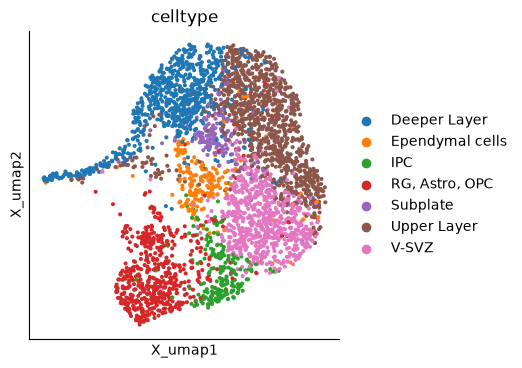

In [24]:
_ = atlas.tl.umap(mudata=with_activity, random_state=seed)
atlas.pl.embedding(mudata=with_activity, color="celltype")

## KNN on a pre-computed matrix
ATLAS can also be applied in scenarios where a pre-computed matrix, e.g. using ``CCA`` or ``MOFA``, is stored into the ``.obsm`` slot of the MuData object.
In this scenario, ATLAS allow the user to compute a KNN grah upon such a representation using the {func}``atlas.pp.knn`` function. 

The {func}``atlas.pp.knn`` requires: 
1. Multiomics data into a {class}``muon.MuData`` object carrying the pre-computed representation.
2. The key under which the representation is sotred in ``.obsm``. 
3. The neighborhood size. 
4. Setting ``copy=True`` does not modify the data inplace.

For the scope of this tutorial we build a demonstrative pre-computed matrix. As a result the KNN is stored into the {class}``muon.MuData`` object under the ``joint`` key. 

In [33]:
rng = np.random.default_rng(seed)
n_cells, n_obs = len(data), 10
key = "fake_matrix"

matrix = rng.normal(size=(n_cells, n_obs))
data.obsm[key] = matrix

In [34]:
integrated = atlas.pp.knn(mudata=data, use_rep=key, random_state=seed, copy=True)
integrated

MuData object with n_obs × n_vars = 3486 × 176722
  obs:	'celltype'
  uns:	'joint'
  obsm:	'fake_matrix'
  obsp:	'joint_distances', 'joint_connectivities'
  2 modalities
    rna:	3486 × 32285
      obs:	'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier'
      var:	'gene_ids', 'feature_types', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg', 'pca'
      obsm:	'X_pca'
      varm:	'PCs'
    atac:	3486 × 144437
      obs:	'n_genes_by_counts', 'total_counts', 'nucleosome_signal', 'nuc_filter', 'tss_s

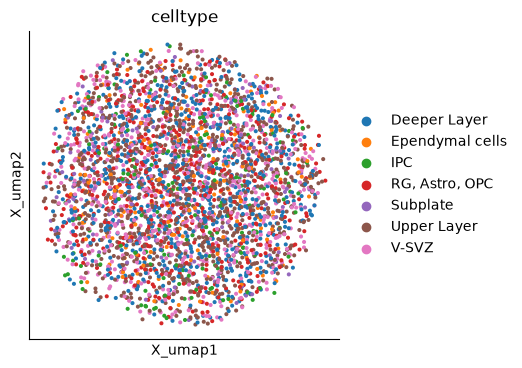

In [35]:
_ = atlas.tl.umap(mudata=integrated, neighbors_key="joint", random_state=seed)
atlas.pl.embedding(mudata=integrated, color="celltype")